In [1]:
import pandas as pd

# load dataset
df = pd.read_excel(r"E:\AAA_projects\Retail Sales_3\retail_raw.xlsx")


In [2]:
df.head()

,Item Purchased,Category,amount,Location,Size,Discount Applied,Promo Code Used,Subscription Status
0,Blouse,Clothing,53,Kentucky,L,Yes,Yes,Yes
1,Sweater,Clothing,64,Maine,L,Yes,Yes,Yes
2,Jeans,Clothing,73,Massachusetts,NaN,Yes,Yes,Yes
3,Blouse,Clothing,49,Oregon,M,Yes,NaN,Yes
4,Shirt,Clothing,85,NaN,M,Yes,Yes,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3246 entries, 0 to 3245
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Item Purchased       3246 non-null   object
 1   Category             3246 non-null   object
 2   amount               3246 non-null   int64 
 3   Location             3245 non-null   object
 4   Size                 3245 non-null   object
 5   Discount Applied     3246 non-null   object
 6   Promo Code Used      3245 non-null   object
 7   Subscription Status  3246 non-null   object
dtypes: int64(1), object(7)
memory usage: 203.0+ KB


In [4]:
df.describe(include='all')

,Item Purchased,Category,amount,Location,Size,Discount Applied,Promo Code Used,Subscription Status
count,3246,3246,3246.000000,3245,3245,3246,3245,3246
unique,21,3,NaN,50,4,2,2,2
top,Blouse,Clothing,NaN,California,M,No,No,No
freq,169,1705,NaN,83,1458,1849,1849,2378
mean,NaN,NaN,60.175909,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,23.407587,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,NaN


In [5]:
# 1. Column standardization
# -----------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [6]:
df.columns

Index(['item_purchased', 'category', 'amount', 'location', 'size',
       'discount_applied', 'promo_code_used', 'subscription_status'],
      dtype='object')

In [7]:
df.isnull().sum()

item_purchased         0
category               0
amount                 0
location               1
size                   1
discount_applied       0
promo_code_used        1
subscription_status    0
dtype: int64

In [9]:
df['location'].fillna(df['location'].mode()[0], inplace=True)
df['size'].fillna(df['size'].mode()[0], inplace=True)
df['promo_code_used'].fillna(df['promo_code_used'].mode()[0], inplace=True)

In [10]:
df.isnull().sum()

item_purchased         0
category               0
amount                 0
location               0
size                   0
discount_applied       0
promo_code_used        0
subscription_status    0
dtype: int64

In [11]:
df.drop_duplicates(inplace=True)

print(df.shape)

(3246, 8)


In [12]:
# These new columns help generate extra insights.
df['discount_flag'] = df['discount_applied'].map({'Yes':1, 'No':0})

df['promo_flag'] = df['promo_code_used'].map({'Yes':1, 'No':0})

df['subscription_flag'] = df['subscription_status'].map({'Yes':1, 'No':0})

In [13]:
df.columns

Index(['item_purchased', 'category', 'amount', 'location', 'size',
       'discount_applied', 'promo_code_used', 'subscription_status',
       'discount_flag', 'promo_flag', 'subscription_flag'],
      dtype='object')

In [14]:
# Create revenue categor
# This separates transactions into high and low revenue.
df['revenue_category'] = df['amount'].apply(
    lambda x: 'High' if x > df['amount'].median() else 'Low'
)

In [15]:
# Product category performance
# This tells:
#  highest revenue category
df.groupby('category')['amount'].sum().sort_values(ascending=False)

category
Clothing       103272
Accessories     73694
Outerwear       18365
Name: amount, dtype: int64

In [16]:
# Item-level revenue contribution
df.groupby('item_purchased')['amount'].sum().sort_values(ascending=False)

item_purchased
Blouse        10370
Shirt         10312
Dress         10280
Pants          9957
Jewelry        9950
Sunglasses     9629
Scarf          9521
Belt           9454
Shorts         9393
Sweater        9323
Skirt          9276
Hat            9271
Coat           9215
Jacket         9150
Socks          9147
T-shirt        9092
Handbag        8796
Hoodie         8614
Backpack       8596
Gloves         8477
Jeans          7508
Name: amount, dtype: int64

In [17]:
# Location-wise revenue
df.groupby('location')['amount'].sum().sort_values(ascending=False)

location
Montana           5124
California        5008
Illinois          4912
Idaho             4901
Nevada            4761
New York          4446
North Dakota      4432
Alabama           4327
Mississippi       4318
West Virginia     4309
Arkansas          4239
New Mexico        4223
Nebraska          4170
Kentucky          4160
Alaska            4154
Louisiana         4127
Pennsylvania      4038
Indiana           3985
Tennessee         3982
North Carolina    3957
Missouri          3934
Delaware          3909
Virginia          3903
Vermont           3898
Washington        3887
Minnesota         3864
Oklahoma          3860
Texas             3859
Arizona           3855
Maryland          3792
Georgia           3778
New Hampshire     3736
South Dakota      3724
Connecticut       3637
Massachusetts     3627
Wyoming           3606
South Carolina    3592
Colorado          3548
Utah              3536
Michigan          3513
Oregon            3510
Wisconsin         3424
Hawaii            3387
Fl

In [18]:
# Size preference analysis
df.groupby('size')['amount'].sum()

size
L     51258
M     87891
S     34413
XL    21769
Name: amount, dtype: int64

In [19]:
# Discount impact
df.groupby('discount_applied')['amount'].mean()

discount_applied
No     60.856679
Yes    59.274875
Name: amount, dtype: float64

In [20]:
#promo code
df.groupby('promo_code_used')['amount'].mean()

promo_code_used
No     60.850270
Yes    59.282235
Name: amount, dtype: float64

In [21]:
#subscription Behaviour
df.groupby('subscription_status')['amount'].sum()

subscription_status
No     143370
Yes     51961
Name: amount, dtype: int64

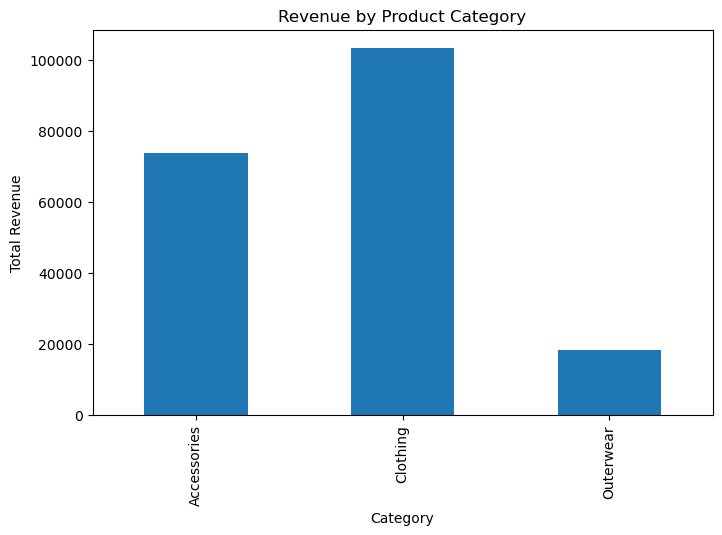

In [22]:
# Product Category Revenue Bar Chart
import matplotlib.pyplot as plt

category_sales = df.groupby('category')['amount'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

plt.show()

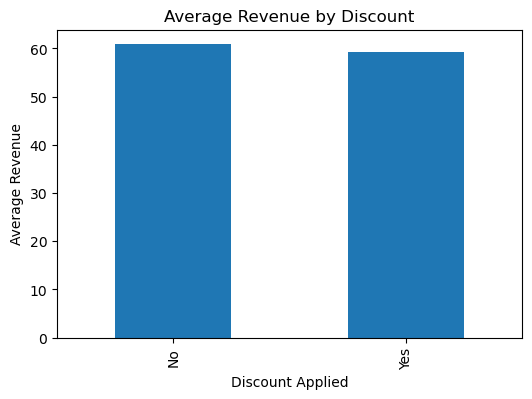

In [23]:
# Discount Impact Chart
discount_sales = df.groupby('discount_applied')['amount'].mean()

plt.figure(figsize=(6,4))
discount_sales.plot(kind='bar')

plt.title('Average Revenue by Discount')
plt.xlabel('Discount Applied')
plt.ylabel('Average Revenue')

plt.show()

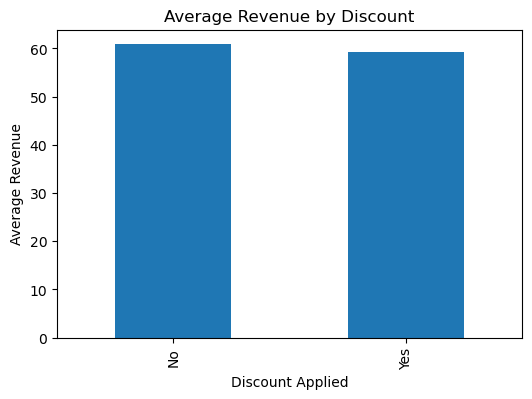

In [24]:
# Discount Impact Chart
discount_sales = df.groupby('discount_applied')['amount'].mean()

plt.figure(figsize=(6,4))
discount_sales.plot(kind='bar')

plt.title('Average Revenue by Discount')
plt.xlabel('Discount Applied')
plt.ylabel('Average Revenue')

plt.show()

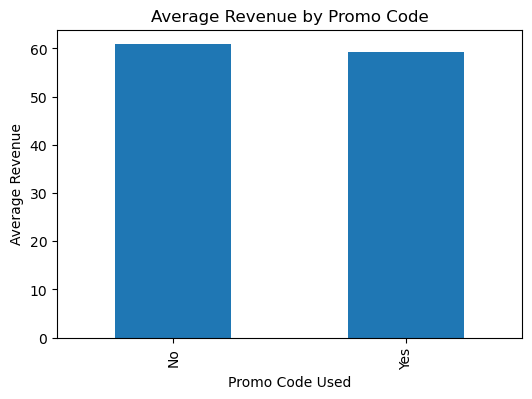

In [25]:
# Promo Code Effectiveness Chart
promo_sales = df.groupby('promo_code_used')['amount'].mean()

plt.figure(figsize=(6,4))
promo_sales.plot(kind='bar')

plt.title('Average Revenue by Promo Code')
plt.xlabel('Promo Code Used')
plt.ylabel('Average Revenue')

plt.show()

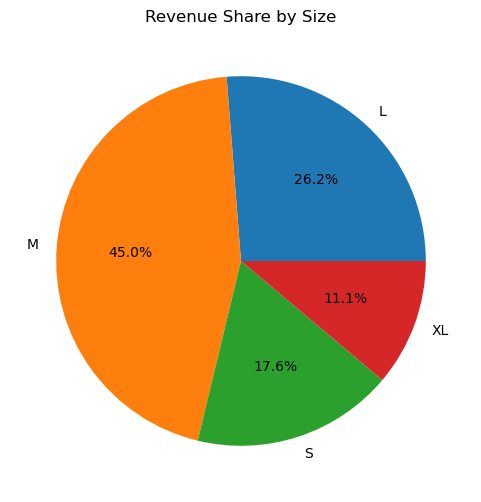

In [26]:
#Size Preference Pie Chart
size_sales = df.groupby('size')['amount'].sum()

plt.figure(figsize=(6,6))
size_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Revenue Share by Size')
plt.ylabel('')

plt.show()

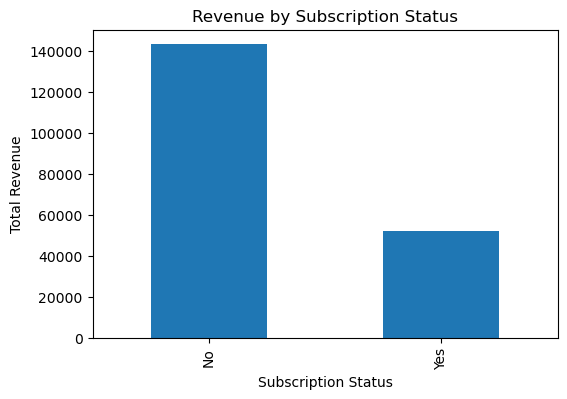

In [27]:
#Subscription Revenue Chart
sub_sales = df.groupby('subscription_status')['amount'].sum()

plt.figure(figsize=(6,4))
sub_sales.plot(kind='bar')

plt.title('Revenue by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Total Revenue')

plt.show()

In [30]:
df.to_excel(r"E:\AAA_projects\Retail Sales_3\retail_final_clean.xlsx",index=False)